## Exercise 1.4 Hotdog -- no hotdog
This is the report hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import random
import copy
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import AutoModel


In [2]:
seed = 0
size = 224
batch_size = 64
num_epochs = 30
lr = 1e-3
weight_decay = 1e-4
use_tta = True
aug = "full"        # "none" | "flip" | "full"
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
run_name = f"dinov3_vits16_aug-{aug}_seed-{seed}"

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


We always check that we are running on a GPU

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"The code will run on {device}.")

The code will run on cuda.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/. Images are resized to a fixed short side below to speed up training.

In [4]:
import gdown
import zipfile

url = "https://drive.google.com/file/d/1iF-r0Tu0kf2Z29auWck0fhjmCaEDUpwR/view?usp=sharing"

data_dir = Path("data")
extract_dir = data_dir / "hotdog_nothotdog"
zip_path = data_dir / "hotdog_nothotdog.zip"

data_dir.mkdir(parents=True, exist_ok=True)

if zip_path.exists() and zipfile.is_zipfile(zip_path):
    print(f"ZIP already exists: {zip_path}")
else:
    if zip_path.exists():
        print(f"Existing file is not a valid ZIP. Removing: {zip_path}")
        zip_path.unlink()

    print("Downloading dataset...")
    gdown.download(url, str(zip_path), quiet=False)

if extract_dir.exists():
    print(f"Dataset already extracted: {extract_dir}")
else:
    print(f"Extracting dataset to: {data_dir}")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete.")


ZIP already exists: data\hotdog_nothotdog.zip
Dataset already extracted: data\hotdog_nothotdog


In [5]:
resized_dir = data_dir / "hotdog_nothotdog_200"

if resized_dir.exists():
    print(f"Resized dataset already exists: {resized_dir}")
else:
    for src in tqdm(glob.glob(str(extract_dir / "*" / "*" / "*.jpg"))):
        img = Image.open(src).convert("RGB")
        w, h = img.size
        scale = 200 / min(w, h)
        img = img.resize((round(w * scale), round(h * scale)), Image.BILINEAR)
        dst = resized_dir / Path(src).relative_to(extract_dir)
        dst.parent.mkdir(parents=True, exist_ok=True)
        img.save(dst, quality=95)

data_path = str(resized_dir)


Resized dataset already exists: data\hotdog_nothotdog_200


In [6]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='./data/hotdog_nothotdog_200', indices=None):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path + '/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        # sorted so file order is deterministic across OS/filesystems
        self.image_paths = sorted(glob.glob(data_path + '/*/*.jpg'))
        if indices is not None:
            self.image_paths = [self.image_paths[i] for i in indices]

    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]

        image = Image.open(image_path).convert('RGB')
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y


We split the train folder into a stratified train/val set (val is used for model selection, test stays untouched until final evaluation).

In [7]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize(int(size * 1.15)),
    transforms.CenterCrop(size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

if aug == "full":
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(size, scale=(0.35, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.TrivialAugmentWide(),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
elif aug == "flip":
    train_transform = transforms.Compose([
        transforms.Resize(int(size * 1.15)),
        transforms.RandomCrop(size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
else:
    train_transform = eval_transform

full_train = Hotdog_NotHotdog(train=True, transform=eval_transform, data_path=data_path)
labels = [full_train.name_to_label[os.path.split(os.path.split(p)[0])[1]] for p in full_train.image_paths]

# stratified 85/15 train/val split of the train folder; test stays untouched
train_idx, val_idx = train_test_split(range(len(labels)), test_size=0.15, stratify=labels, random_state=42)

trainset = Hotdog_NotHotdog(train=True, transform=train_transform, data_path=data_path, indices=train_idx)
valset = Hotdog_NotHotdog(train=True, transform=eval_transform, data_path=data_path, indices=val_idx)
testset = Hotdog_NotHotdog(train=False, transform=eval_transform, data_path=data_path)

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

class_names = sorted(full_train.name_to_label, key=full_train.name_to_label.get)


Let's look at some images from our data 

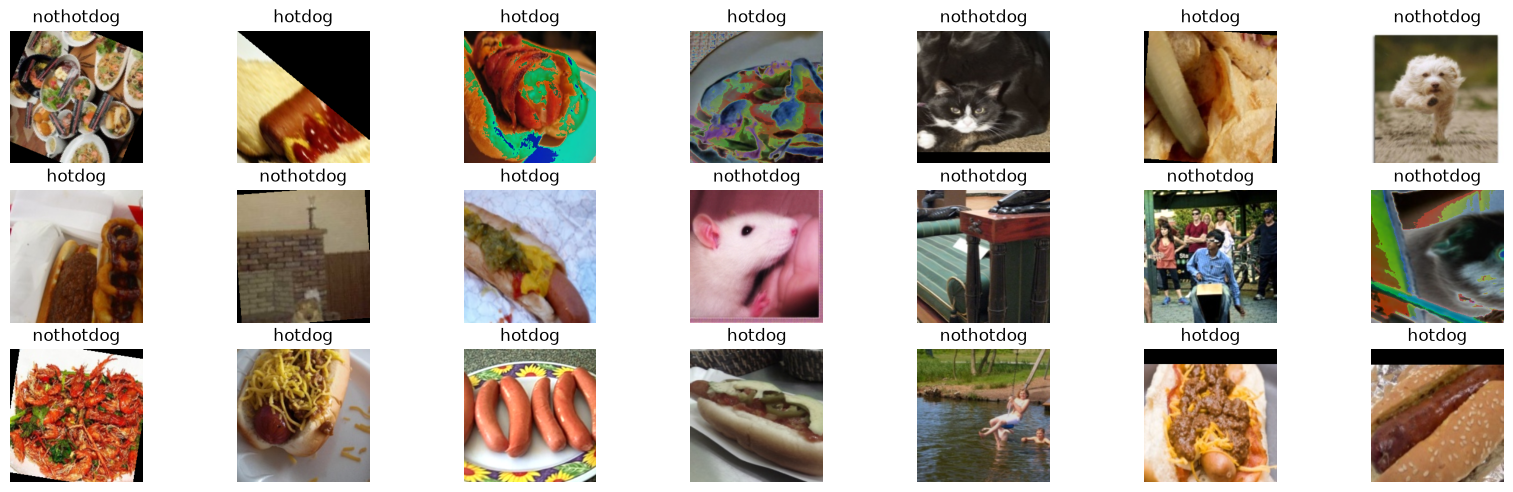

In [8]:
images, labels = next(iter(train_loader))

mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)

plt.figure(figsize=(20, 10))

for i in range(21):
    plt.subplot(5, 7, i + 1)

    image = images[i] * std_t + mean_t
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0)

    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis('off')


Now create a model and train it! We use a frozen DINOv3 ViT-S/16 backbone as a feature extractor, with a small trainable linear head on top (linear probing).

In [9]:
class Network(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(model_name)
        self.backbone.eval()
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.fully_connected = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.backbone.config.hidden_size, 1)
        )

    def train(self, mode=True):
        # keep the frozen DINO backbone in eval mode regardless of model.train()/eval()
        super().train(mode)
        self.backbone.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(pixel_values=x).pooler_output

        return self.fully_connected(features).squeeze(1)


model = Network(model_name=model_name)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total parameters: {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 86.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

total parameters: 21,596,929
trainable parameters: 385


In [10]:
optimizer = torch.optim.AdamW(model.fully_connected.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


In [11]:
history = []
best_val_acc = -1
best_head_state = None

for epoch in tqdm(range(num_epochs), unit='epoch'):
    model.train()
    train_correct = 0
    train_loss = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device).float()

        optimizer.zero_grad()

        output = model(data)
        loss = F.binary_cross_entropy_with_logits(output, target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        predicted = (output > 0).long()
        train_correct += (target.long() == predicted).sum().item()

    scheduler.step()

    model.eval()
    val_correct = 0
    val_loss = 0

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device).float()

            output = model(data)
            loss = F.binary_cross_entropy_with_logits(output, target)

            val_loss += loss.item()
            predicted = (output > 0).long()
            val_correct += (target.long() == predicted).sum().item()

    train_acc = train_correct / len(trainset)
    val_acc = val_correct / len(valset)

    history.append(dict(epoch=epoch, train_loss=train_loss / len(train_loader), train_acc=train_acc,
                         val_loss=val_loss / len(val_loader), val_acc=val_acc, lr=optimizer.param_groups[0]['lr']))

    print(
        f"Loss: {train_loss / len(train_loader):.4f}	"
        f"Train: {100 * train_acc:.1f}%	"
        f"Val: {100 * val_acc:.1f}%	"
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_head_state = copy.deepcopy(model.fully_connected.state_dict())


  0%|          | 0/30 [00:00<?, ?epoch/s]

Loss: 0.5651	Train: 73.8%	Val: 84.7%	LR: 0.000997
Loss: 0.3987	Train: 87.1%	Val: 89.9%	LR: 0.000989
Loss: 0.3170	Train: 90.8%	Val: 92.9%	LR: 0.000976
Loss: 0.2774	Train: 91.7%	Val: 94.5%	LR: 0.000957
Loss: 0.2433	Train: 93.2%	Val: 95.1%	LR: 0.000933
Loss: 0.2278	Train: 93.6%	Val: 95.1%	LR: 0.000905
Loss: 0.2095	Train: 94.0%	Val: 95.5%	LR: 0.000872
Loss: 0.1976	Train: 94.0%	Val: 96.4%	LR: 0.000835
Loss: 0.1904	Train: 94.2%	Val: 96.8%	LR: 0.000794
Loss: 0.1795	Train: 95.1%	Val: 96.8%	LR: 0.000750
Loss: 0.1706	Train: 94.5%	Val: 96.4%	LR: 0.000703
Loss: 0.1623	Train: 95.3%	Val: 96.4%	LR: 0.000655
Loss: 0.1645	Train: 95.3%	Val: 97.1%	LR: 0.000604
Loss: 0.1617	Train: 95.3%	Val: 97.1%	LR: 0.000552
Loss: 0.1560	Train: 95.5%	Val: 97.1%	LR: 0.000500
Loss: 0.1534	Train: 95.1%	Val: 97.1%	LR: 0.000448
Loss: 0.1486	Train: 95.3%	Val: 97.4%	LR: 0.000396
Loss: 0.1481	Train: 95.3%	Val: 97.4%	LR: 0.000345
Loss: 0.1475	Train: 95.1%	Val: 97.4%	LR: 0.000297
Loss: 0.1412	Train: 96.0%	Val: 97.4%	LR: 0.000250


In [12]:
model.fully_connected.load_state_dict(best_head_state)
model.eval()

test_correct = 0
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        logits = model(data)
        if use_tta:
            logits = (logits + model(torch.flip(data, dims=[3]))) / 2

        probs = torch.sigmoid(logits)
        predicted = (logits > 0).long()

        test_correct += (predicted == target).sum().item()
        all_preds.append(predicted.cpu())
        all_targets.append(target.cpu())
        all_probs.append(probs.cpu())

final_test_acc = test_correct / len(testset)
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)
all_probs = torch.cat(all_probs)

print(f"Final test accuracy: {100 * final_test_acc:.2f}%")
print("classes:", class_names)
print(confusion_matrix(all_targets, all_preds))

results_dir = Path("results") / run_name
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(history).to_csv(results_dir / "history.csv", index=False)

config = dict(
    model_name=model_name, frozen_backbone=True,
    seed=seed, size=size, batch_size=batch_size, num_epochs=num_epochs,
    lr=lr, weight_decay=weight_decay, use_tta=use_tta, aug=aug,
    test_acc=final_test_acc,
)
with open(results_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)

torch.save(best_head_state, results_dir / "best_head.pt")


Final test accuracy: 96.19%
classes: ['hotdog', 'nothotdog']
[[871  24]
 [ 47 920]]


## Diagnostics

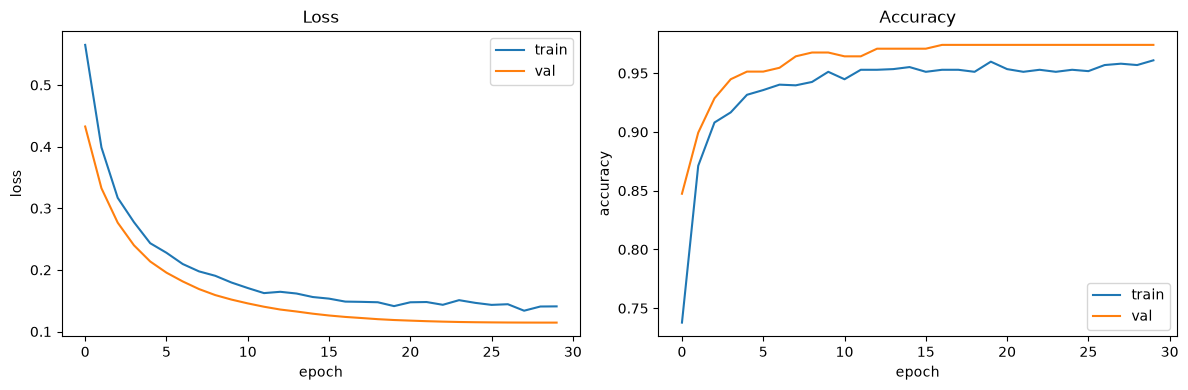

In [13]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(hist_df['epoch'], hist_df['train_acc'], label='train')
axes[1].plot(hist_df['epoch'], hist_df['val_acc'], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend(); axes[1].set_title('Accuracy')

plt.tight_layout()
plt.show()


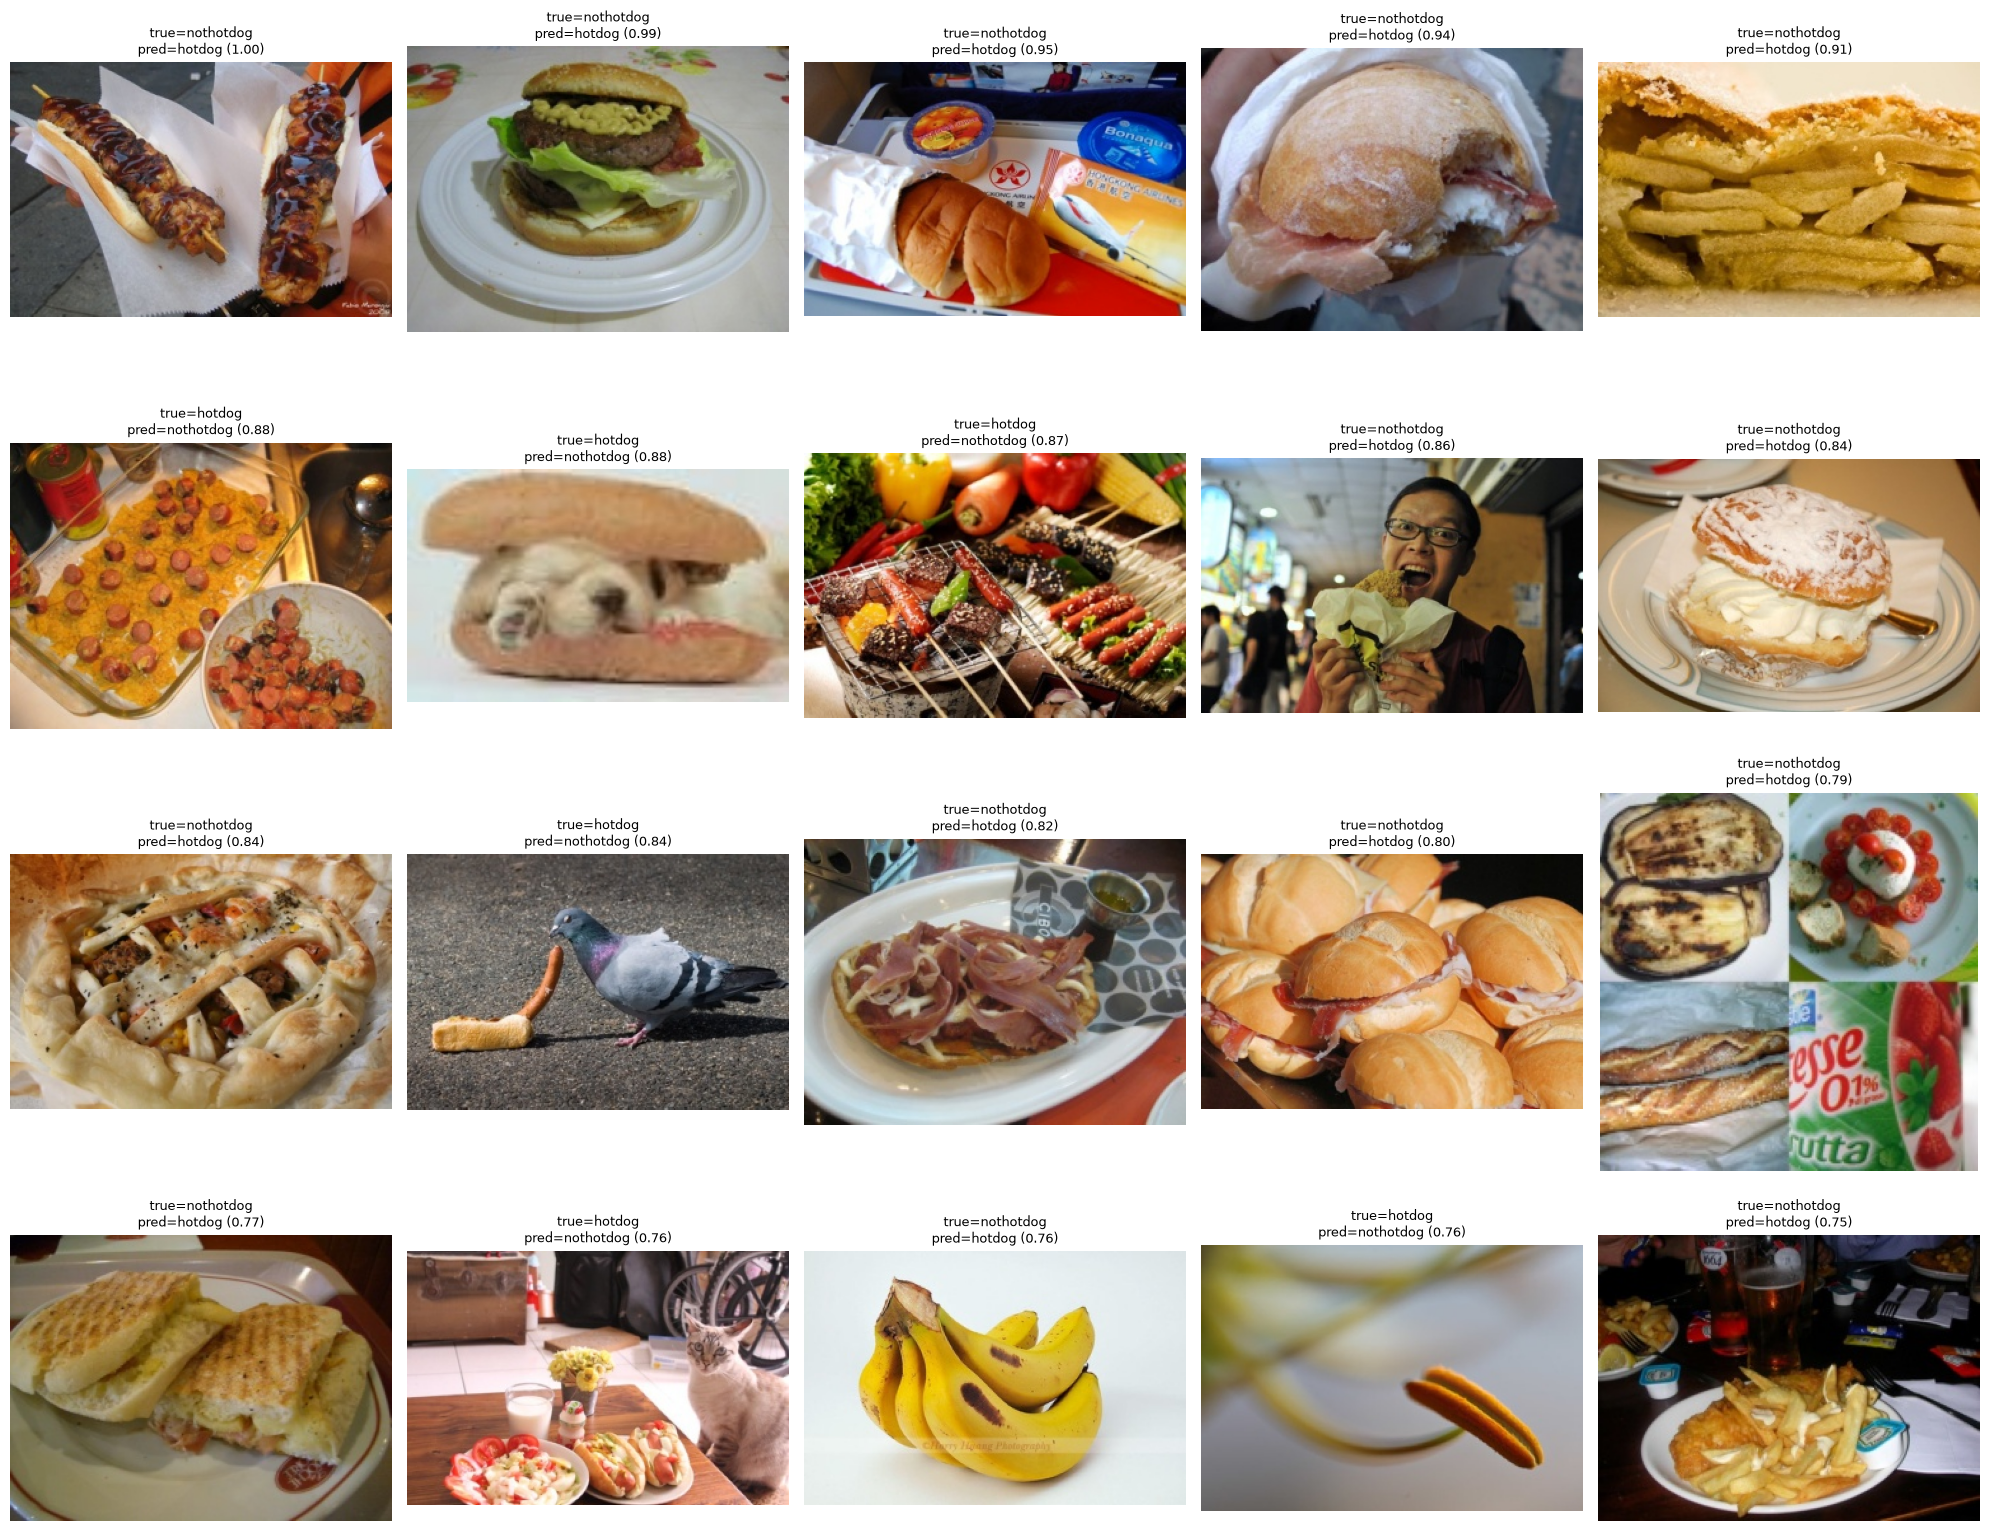

In [14]:
wrong = (all_preds != all_targets).nonzero(as_tuple=True)[0]
conf = torch.where(all_preds[wrong] == 1, all_probs[wrong], 1 - all_probs[wrong])
order = conf.argsort(descending=True)[:20]
worst, worst_conf = wrong[order], conf[order]

cols = 5
rows = -(-len(worst) // cols)
plt.figure(figsize=(4 * cols, 4 * rows))
for i, idx in enumerate(worst):
    image = Image.open(testset.image_paths[idx]).convert('RGB')
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image)
    plt.title(f"true={class_names[all_targets[idx]]}\npred={class_names[all_preds[idx]]} ({worst_conf[i]:.2f})", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


### Ablation grid (run manually, 3 seeds each, by editing the config cell)

- **Baseline**: defaults as set in the config cell (linear probe on frozen DINOv3 features).
- **Augmentation**: `aug="none"`, `aug="flip"`, `aug="full"`.
- **TTA**: `use_tta=True` vs `use_tta=False`.

For each run, vary `seed` across 3 values and record `results/<run_name>/config.json` + `history.csv`.